In [2]:
from climada.hazard.tc_tracks import TCTracks

In [3]:
STORM_LN = TCTracks.from_simulations_storm(
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_0.txt"
)
STORM_EN = TCTracks.from_simulations_storm(
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_0.txt"
)
STORM_NEU = TCTracks.from_simulations_storm(
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_0.txt"
)

STORM_LN_old = TCTracks.from_simulations_storm(
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021LANINA/IB1980-2021LANINA_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_0.txt"
)
STORM_EN_old = TCTracks.from_simulations_storm(
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ELNINO/IB1980-2021ELNINO_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_0.txt"
)
STORM_NEU_old = TCTracks.from_simulations_storm(
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ENSO_NEUTRAL/IB1980-2021ENSO_NEUTRAL_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_0.txt"
)

In [4]:
a = TCTracks.from_ibtracs_netcdf(basin="NA", year_range=(1980,2020))

2026-03-29 18:49:24,681 - climada.hazard.tc_tracks - WARNING - The cached IBTrACS data set dates from 2025-06-04 02:47:07 (older than 180 days). Very likely, a more recent version is available. Consider manually removing the file /home/mbaldacchino/climada/data/IBTrACS.ALL.v04r01.nc and re-running this function, which will download the most recent version of the IBTrACS data set from the official URL.
2026-03-29 19:01:45,447 - climada.hazard.tc_tracks - WARNING - 57 storm events are discarded because no valid wind/pressure values have been found: 1980199N31284, 1980200N25270, 1980204N23287, 1980226N15339, 1980238N16328, ...


In [ ]:
import numpy as np
from climada.hazard import TCTracks
from climada.hazard.tc_tracks import set_category


def keep_only_ts_points(track, ts_threshold_kn=34):
    # pointwise mask: keep only TS or stronger points
    mask = track["max_sustained_wind"].values >= ts_threshold_kn

    # storm never reached TS
    if not mask.any():
        return None

    # subset in time
    tr = track.isel(time=mask).copy()

    # avoid single-point tracks
    if tr.sizes["time"] < 2:
        return None

    # recompute time_step after dropping TD points
    dt_h = np.diff(tr["time"].values) / np.timedelta64(1, "h")
    tr["time_step"] = ("time", np.r_[dt_h[0], dt_h].astype(float))

    # keep attrs and recompute category on the trimmed track
    tr.attrs = dict(track.attrs)
    tr.attrs["category"] = set_category(
        tr["max_sustained_wind"].values,
        wind_unit=tr.attrs.get("max_sustained_wind_unit", "kn"),
    )

    return tr


a = TCTracks.from_ibtracs_netcdf(basin="NA", year_range=(1980, 2020))


2026-03-29 19:01:51,151 - climada.hazard.tc_tracks - WARNING - The cached IBTrACS data set dates from 2025-06-04 02:47:07 (older than 180 days). Very likely, a more recent version is available. Consider manually removing the file /home/mbaldacchino/climada/data/IBTrACS.ALL.v04r01.nc and re-running this function, which will download the most recent version of the IBTrACS data set from the official URL.
2026-03-29 19:11:27,102 - climada.hazard.tc_tracks - WARNING - 57 storm events are discarded because no valid wind/pressure values have been found: 1980199N31284, 1980200N25270, 1980204N23287, 1980226N15339, 1980238N16328, ...


In [ ]:

filtered = []
for track in a.data:
    # 1) drop storms that never became TS
    if track.attrs["category"] < 0:
        continue

    # 2) keep only TS+ parts of the lifecycle
    tr = keep_only_ts_points(track)

    if tr is not None:
        filtered.append(tr)

a_ts = TCTracks(data=filtered, pool=a.pool)


In [9]:
a_ts.data

[<xarray.Dataset> Size: 4kB
 Dimensions:                 (time: 76)
 Coordinates:
   * time                    (time) datetime64[ns] 608B 1980-08-02 ... 1980-08...
     lat                     (time) float32 304B 11.0 11.2 11.4 ... 28.0 28.2
     lon                     (time) float32 304B -42.8 -43.8 ... -100.9 -101.4
 Data variables:
     radius_max_wind         (time) float32 304B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
     radius_oci              (time) float32 304B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
     max_sustained_wind      (time) float32 304B 35.0 40.0 45.0 ... 45.0 38.0
     central_pressure        (time) float32 304B 1.005e+03 ... 1.003e+03
     environmental_pressure  (time) float64 608B 1.01e+03 1.01e+03 ... 1.01e+03
     time_step               (time) float64 608B 3.0 3.0 3.0 3.0 ... 3.0 3.0 3.0
     basin                   (time) <U2 608B 'NA' 'NA' 'NA' ... 'NA' 'NA' 'NA'
 Attributes:
     max_sustained_wind_unit:  kn
     central_pressure_unit:    mb
     orig_event_flag:       

In [6]:
import pandas as pd
import numpy as np

def summarize_basin(tc_tracks, type="STORM"):
    data = tc_tracks.data
    if type=="STORM":
        year_val = [int(i.id_no/1_000) for i in data]
    else:
        year_val = [int(i.sid[:4]) for i in data]
    
    out_df = pd.DataFrame({"year" : np.arange(min(year_val), max(year_val))})
    # get avg storm/year
    out_df["avg_count"] = [len([y_i for y_i in year_val if y_i == year]) for year in out_df["year"]]

    # get avg pressure along track
    storm_avg_press = [
        data[i].mean().central_pressure.values
        for i in range (len(year_val))]
    
    out_df["avg_press"] = [np.mean([storm_avg_press[i] for i in range(len(storm_avg_press)) if year_val[i] == year]) for year in out_df["year"]]

    # get min pressure track
    storm_min_press = [
        data[i].min().central_pressure.values for i in range(len(year_val))
    ]

    out_df["min_press"] = [
        np.mean(
            [
                storm_min_press[i]
                for i in range(len(storm_min_press))
                if year_val[i] == year
            ]
        )
        for year in out_df["year"]
    ]

    # max wind
    storm_max_wind = [
        data[i].max().max_sustained_wind.values for i in range(len(year_val))
    ]

    out_df["max_wind"] = [
        np.mean(
            [
                storm_max_wind[i]
                for i in range(len(storm_max_wind))
                if year_val[i] == year
            ]
        )
        for year in out_df["year"]
    ]

    # get wind landfall 


    # get pressure genesis
    storm_gen_press = [
        data[i].central_pressure.values[0] for i in range(len(year_val))
    ]

    out_df["gen_press"] = [
        np.mean(
            [
                storm_gen_press[i]
                for i in range(len(storm_gen_press))
                if year_val[i] == year
            ]
        )
        for year in out_df["year"]
    ]

    # get radius max wind
    storm_rad_max = [data[i].mean().radius_max_wind.values for i in range(len(year_val))]

    out_df["rad_max"] = [
        np.mean(
            [
                storm_rad_max[i]
                for i in range(len(storm_rad_max))
                if year_val[i] == year
            ]
        )
        for year in out_df["year"]
    ]


    return out_df


    



In [7]:
ibtracs = summarize_basin(a_ts, type="IBTRACS")
storm_nina = summarize_basin(STORM_LN, type="STORM")
storm_nino = summarize_basin(STORM_EN, type="STORM")
storm_neutral = summarize_basin(STORM_NEU, type="STORM")

storm_nina_old = summarize_basin(STORM_LN_old, type="STORM")
storm_nino_old = summarize_basin(STORM_EN_old, type="STORM")
storm_neutral_old = summarize_basin(STORM_NEU_old, type="STORM")


/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mbaldacchino/miniconda/envs/cat/lib/python3.13

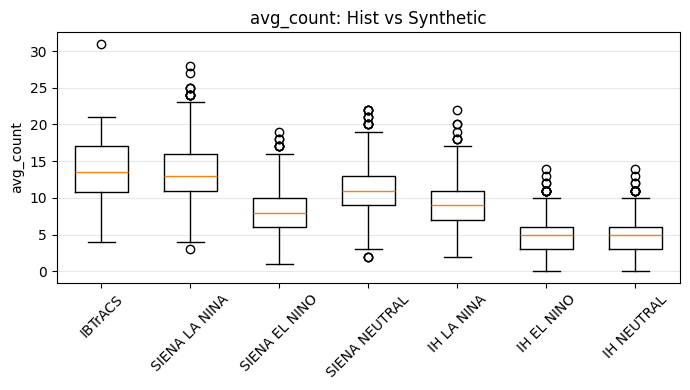

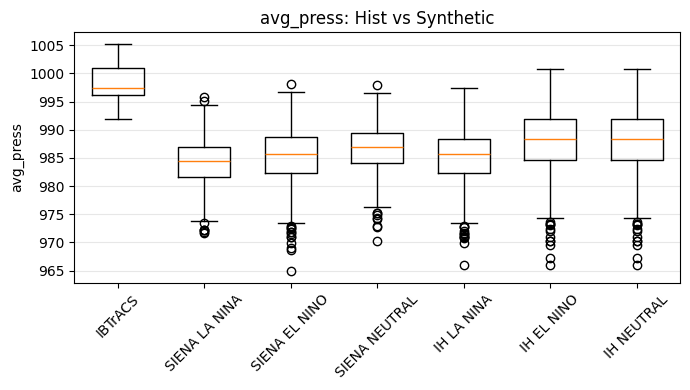

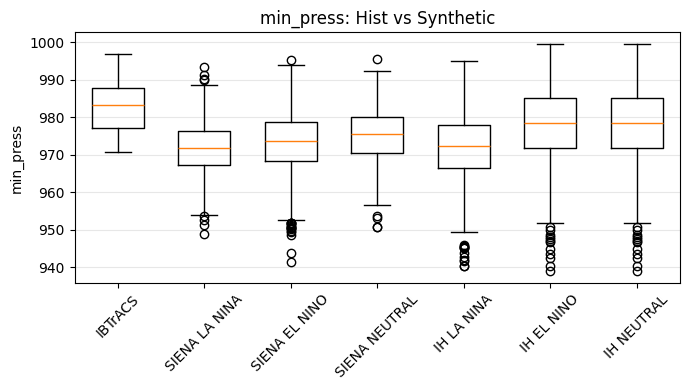

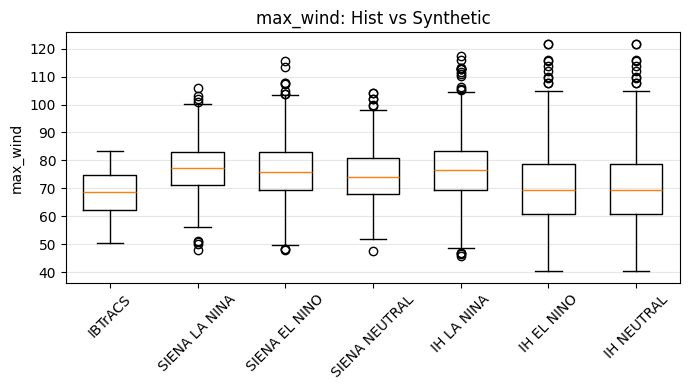

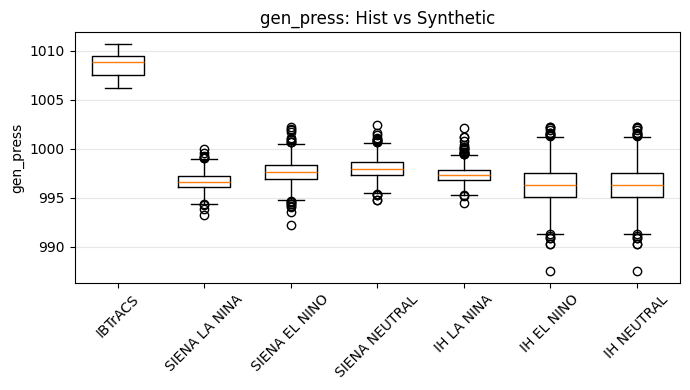

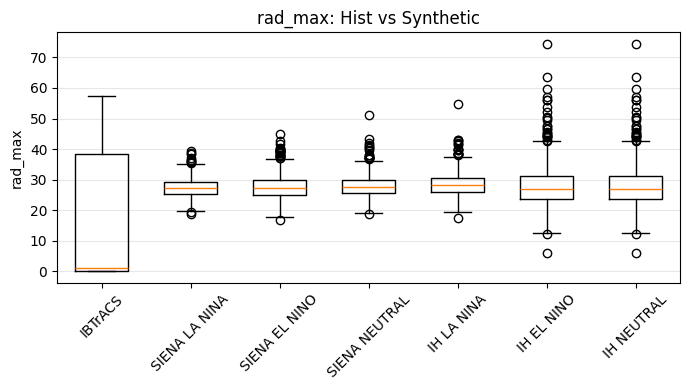

In [7]:
df1 = ibtracs.copy()
# SIENA IH STORM
df2 = storm_nina.copy()
df3 = storm_nino.copy()
df4 = storm_neutral.copy()

# IH STORM
df5 = storm_nina_old.copy()
df6 = storm_nino_old.copy()
df7 = storm_neutral_old.copy()


import pandas as pd
import matplotlib.pyplot as plt

# columns to compare: common numeric columns, excluding 'year'
cols = [
    c
    for c in df1.columns.intersection(df2.columns)
    if c != "year"
    and pd.api.types.is_numeric_dtype(df1[c])
    and pd.api.types.is_numeric_dtype(df2[c])
]

for col in cols:
    data1 = df1[col].dropna()
    data2 = df2[col].dropna()
    data3 = df3[col].dropna()
    data4 = df4[col].dropna()
    data5 = df5[col].dropna()
    data6 = df6[col].dropna()
    data7 = df7[col].dropna()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.boxplot([data1, data2, data3, data4, data5, data6, data7],
                tick_labels=["IBTrACS", "SIENA LA NINA", "SIENA EL NINO","SIENA NEUTRAL", "IH LA NINA", "IH EL NINO", "IH NEUTRAL"],
                  widths=0.6)
    ax.tick_params(axis='x', labelrotation=45)

    ax.set_title(f"{col}: Hist vs Synthetic")
    ax.set_ylabel(col)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

# Compare with Hist

# Compare with ENSO-STORM

In [112]:
"""
Plot difference maps of ACE, track density, and genesis density
between SIENA-IH-STORM, old IH-STORM, and IBTrACS.

Produces a multi-panel figure in the style of Odériz & Losada (2025).

Dependencies:
    pip install numpy matplotlib cartopy climada

Author: adapted for comparison workflow
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from climada.hazard import TCTracks

# =============================================================================
# USER CONFIGURATION — edit paths here
# =============================================================================

# --- SIENA-IH-STORM (new model) ---
SIENA_PATHS = {
    "LN": "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_0.txt",
    "EN": "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_0.txt",
    "NEU": "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_0.txt",
}

# --- Old IH-STORM ---
OLD_PATHS = {
    "LN": "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021LANINA/IB1980-2021LANINA_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_0.txt",
    "EN": "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ELNINO/IB1980-2021ELNINO_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_0.txt",
    "NEU": "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ENSO_NEUTRAL/IB1980-2021ENSO_NEUTRAL_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_0.txt",
}

# Basin config
BASIN = "NA"
N_YEARS = 1000  # number of simulated years per file

# Grid resolution (degrees)
GRID_RES = 2.0

# NA basin bounds (lon in 0–360)
LON_MIN, LON_MAX = 255, 359
LAT_MIN, LAT_MAX = 5, 60

# Which ENSO phases to plot (one panel row per phase)
PHASES = ["EN", "LN","NEU"]  # extend to ["EN", "LN", "NEU"] if needed

# IBTrACS period matching the model calibration
IBTRACS_YEARS = (1980, 2020)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================


def load_storm_txt(filepath):
    """Load a STORM-format .txt file into a structured dict of arrays."""
    data = np.loadtxt(filepath, delimiter=",")
    return {
        "year": data[:, 0].astype(int),
        "month": data[:, 1].astype(int),
        "storm_id": data[:, 2].astype(int),
        "timestep": data[:, 3].astype(int),
        "basin": data[:, 4].astype(int),
        "lat": data[:, 5],
        "lon": data[:, 6],  # 0–360
        "pmin": data[:, 7],  # hPa
        "vmax": data[:, 8]/0.88,  # m/s (10-min sustained)
        "rmax": data[:, 9],  # km
        "category": data[:, 10].astype(int),
        "landfall": data[:, 11].astype(int),
        "dist_land": data[:, 12],
    }


def load_ibtracs_na(year_range, basin_name="NA"):
    """
    Load IBTrACS data for the North Atlantic via CLIMADA.
    Returns a dict with lat, lon, vmax, timestep, year, storm_id arrays
    in the same convention as STORM (lon 0–360).
    """
    tracks = TCTracks.from_ibtracs_netcdf(
        #provider="usa",
        year_range=year_range,
        basin=basin_name,
    )
    # Flatten all tracks into arrays
    lats, lons, vmax_arr = [], [], []
    years, tsteps, sids = [], [], []
    for sid, tr in enumerate(tracks.data):
        n = len(tr.time)
        lats.append(tr.lat.values)
        lon_vals = tr.lon.values % 360  # convert to 0–360
        lons.append(lon_vals)
        # CLIMADA stores max_sustained_wind in kn by default — convert to m/s
        wind = tr.max_sustained_wind.values
        if hasattr(tr.max_sustained_wind, "attrs"):
            units = tr.max_sustained_wind.attrs.get("units", "kn")
        else:
            units = "kn"
        if units == "kn":
            wind = wind * 0.51444
        vmax_arr.append(wind)
        tsteps.append(np.arange(n))
        years.append(np.full(n, tr.time.dt.year.values[0]))
        sids.append(np.full(n, sid))
    return {
        "lat": np.concatenate(lats),
        "lon": np.concatenate(lons),
        "vmax": np.concatenate(vmax_arr),
        "timestep": np.concatenate(tsteps),
        "year": np.concatenate(years),
        "storm_id": np.concatenate(sids),
    }


def make_grid(lon_min, lon_max, lat_min, lat_max, res):
    """Create grid edges and centres."""
    lon_edges = np.arange(lon_min, lon_max + res, res)
    lat_edges = np.arange(lat_min, lat_max + res, res)
    lon_c = 0.5 * (lon_edges[:-1] + lon_edges[1:])
    lat_c = 0.5 * (lat_edges[:-1] + lat_edges[1:])
    return lon_edges, lat_edges, lon_c, lat_c


def track_density(data, lon_edges, lat_edges, n_years):
    """
    Track density: number of unique storms passing through each cell per year.
    Counts each storm only once per cell.
    """
    ny = len(lat_edges) - 1
    nx = len(lon_edges) - 1
    density = np.zeros((ny, nx))

    # Build storm-unique identifier
    uid = data["year"] * 10000 + data["storm_id"]
    unique_storms = np.unique(uid)

    for storm in unique_storms:
        mask = uid == storm
        lon_s = data["lon"][mask]
        lat_s = data["lat"][mask]
        # Bin each point, then take unique cells
        ix = np.digitize(lon_s, lon_edges) - 1
        iy = np.digitize(lat_s, lat_edges) - 1
        valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)
        cells = set(zip(iy[valid], ix[valid]))
        for r, c in cells:
            density[r, c] += 1

    return density / n_years


def genesis_density(data, lon_edges, lat_edges, n_years):
    """Genesis density: number of genesis events (timestep==0) per cell per year."""
    ny = len(lat_edges) - 1
    nx = len(lon_edges) - 1
    density = np.zeros((ny, nx))

    mask = data["timestep"] == 0
    lon_g = data["lon"][mask]
    lat_g = data["lat"][mask]

    ix = np.digitize(lon_g, lon_edges) - 1
    iy = np.digitize(lat_g, lat_edges) - 1
    valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)
    for r, c in zip(iy[valid], ix[valid]):
        density[r, c] += 1

    return density / n_years


def ace_density(data, lon_edges, lat_edges, n_years, dt_hours=3):
    """
    ACE density per grid cell per year.
    ACE = sum(v_max^2) at each 6-hourly (or 3-hourly) step.
    Units: 10^-4 kn^2 / year  (matching the reference figure).
    Input vmax is in m/s; convert to knots for ACE convention.
    DOUBLE CHECK THE 10min or 1min
    """
    ny = len(lat_edges) - 1
    nx = len(lon_edges) - 1
    density = np.zeros((ny, nx))

    vmax_kn = data["vmax"] / 0.51444  # m/s -> kn

    ix = np.digitize(data["lon"], lon_edges) - 1
    iy = np.digitize(data["lat"], lat_edges) - 1
    valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)

    for r, c, v in zip(iy[valid], ix[valid], vmax_kn[valid]):
        density[r, c] += v**2

    # Scale: ACE convention uses 10^-4 kn^2
    return density * 1e-4 / n_years


# =============================================================================
# PLOTTING HELPERS
# =============================================================================


def lon360_to_180(lon):
    """Convert longitude from 0–360 to –180–180."""
    return np.where(lon > 180, lon - 360, lon)


def make_diverging_cmap_ace():
    """Purple–white–orange diverging colormap for ACE (matching reference)."""
    colors_neg = plt.cm.Purples_r(np.linspace(0.0, 1.0, 128))
    colors_pos = plt.cm.Oranges(np.linspace(0.0, 1.0, 128))
    all_colors = np.vstack([colors_neg, colors_pos])
    return mcolors.LinearSegmentedColormap.from_list("ace_div", all_colors)


def make_diverging_cmap_track():
    """Blue–white–red diverging colormap for track density."""
    colors_neg = plt.cm.Blues_r(np.linspace(0.0, 1.0, 128))
    colors_pos = plt.cm.Reds(np.linspace(0.0, 1.0, 128))
    all_colors = np.vstack([colors_neg, colors_pos])
    return mcolors.LinearSegmentedColormap.from_list("track_div", all_colors)


def make_diverging_cmap_genesis():
    """Magenta–white–green diverging colormap for genesis density."""
    colors_neg = plt.cm.RdPu_r(np.linspace(0.0, 1.0, 128))
    colors_pos = plt.cm.Greens(np.linspace(0.0, 1.0, 128))
    all_colors = np.vstack([colors_neg, colors_pos])
    return mcolors.LinearSegmentedColormap.from_list("gen_div", all_colors)


def plot_difference_panel(
    ax,
    lon_c,
    lat_c,
    diff,
    cmap,
    vmin,
    vmax,
    label,
    title=None,
):
    """Plot a single difference map panel on a Cartopy GeoAxes."""
    lon_c_180 = lon360_to_180(lon_c)
    # Sort by longitude for correct pcolormesh rendering
    sort_idx = np.argsort(lon_c_180)
    lon_sorted = lon_c_180[sort_idx]
    diff_sorted = diff[:, sort_idx]

    LON, LAT = np.meshgrid(lon_sorted, lat_c)
    im = ax.pcolormesh(
        LON,
        LAT,
        diff_sorted,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree(),
        shading="auto",
    )
    ax.add_feature(cfeature.LAND, facecolor="lightgrey", edgecolor="none", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=3)
    ax.set_extent(
        [
            lon360_to_180(np.array([LON_MIN]))[0],
            lon360_to_180(np.array([LON_MAX]))[0],
            LAT_MIN,
            LAT_MAX,
        ],
        crs=ccrs.PlateCarree(),
    )
    # Panel label
    ax.text(
        0.02,
        0.92,
        label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="square,pad=0.15"),
        va="top",
        ha="left",
        zorder=5,
    )
    if title:
        ax.set_title(title, fontsize=10, pad=4)
    return im


def add_shared_colorbar(fig, axes_row, im, label, orientation="horizontal"):
    """Add a single colorbar below a row of axes."""
    # Get bounding box of the row
    pos0 = axes_row[0].get_position()
    pos1 = axes_row[-1].get_position()
    cbar_ax = fig.add_axes([pos0.x0, pos0.y0 - 0.045, pos1.x1 - pos0.x0, 0.015])
    cb = fig.colorbar(im, cax=cbar_ax, orientation=orientation, extend="both")
    cb.set_label(label, fontsize=10)
    cb.ax.tick_params(labelsize=8)
    return cb



In [ ]:

# =============================================================================
# MAIN
# =============================================================================

# --- Build grid ---
lon_edges, lat_edges, lon_c, lat_c = make_grid(
    LON_MIN, LON_MAX, LAT_MIN, LAT_MAX, GRID_RES
)

# --- Load IBTrACS ---
print("Loading IBTrACS …")
ibtracs = load_ibtracs_na(IBTRACS_YEARS)
n_years_obs = IBTRACS_YEARS[1] - IBTRACS_YEARS[0] + 1


Loading IBTrACS …
2026-03-17 13:33:54,379 - climada.hazard.tc_tracks - WARNING - The cached IBTrACS data set dates from 2025-06-04 02:47:07 (older than 180 days). Very likely, a more recent version is available. Consider manually removing the file /home/mbaldacchino/climada/data/IBTrACS.ALL.v04r01.nc and re-running this function, which will download the most recent version of the IBTrACS data set from the official URL.
2026-03-17 13:36:16,527 - climada.hazard.tc_tracks - WARNING - 57 storm events are discarded because no valid wind/pressure values have been found: 1980199N31284, 1980200N25270, 1980204N23287, 1980226N15339, 1980238N16328, ...
Computing IBTrACS densities …
Loading SIENA EN …
Loading Old IH-STORM EN …
Loading SIENA LN …
Loading Old IH-STORM LN …
Saved → diff_ace_NA.png
Saved → diff_track_NA.png
Saved → diff_gen_NA.png
Done.


In [ ]:

# --- Compute IBTrACS densities ---
print("Computing IBTrACS densities …")
ibt_track = track_density(ibtracs, lon_edges, lat_edges, n_years_obs)
ibt_gen = genesis_density(ibtracs, lon_edges, lat_edges, n_years_obs)
ibt_ace = ace_density(ibtracs, lon_edges, lat_edges, n_years_obs, dt_hours=3)

# --- Load model data and compute densities per phase ---
siena, old = {}, {}
for phase in PHASES:
    print(f"Loading SIENA {phase} …")
    s = load_storm_txt(SIENA_PATHS[phase])
    siena[phase] = {
        "track": track_density(s, lon_edges, lat_edges, N_YEARS),
        "gen": genesis_density(s, lon_edges, lat_edges, N_YEARS),
        "ace": ace_density(s, lon_edges, lat_edges, N_YEARS, dt_hours=3),
    }
    print(f"Loading Old IH-STORM {phase} …")
    o = load_storm_txt(OLD_PATHS[phase])
    old[phase] = {
        "track": track_density(o, lon_edges, lat_edges, N_YEARS),
        "gen": genesis_density(o, lon_edges, lat_edges, N_YEARS),
        "ace": ace_density(o, lon_edges, lat_edges, N_YEARS, dt_hours=3),
    }


Computing IBTrACS densities …
Loading SIENA EN …
Loading Old IH-STORM EN …
Loading SIENA LN …
Loading Old IH-STORM LN …
Loading SIENA NEU …
Loading Old IH-STORM NEU …


In [115]:

# =========================================================================
# FIGURE: 3 variable blocks × (n_phases × 3 comparisons)
# Layout per variable: rows = phases, cols = [SIENA−IBTrACS, Old−IBTrACS, SIENA−Old]
# =========================================================================

n_phases = len(PHASES)
n_cols = 3  # comparisons
comp_labels = ["SIENA − IBTrACS", "Old IH-STORM − IBTrACS", "SIENA − Old IH-STORM"]

# --- Colormaps and limits ---
cmap_ace = make_diverging_cmap_ace()
cmap_trk = make_diverging_cmap_track()
cmap_gen = make_diverging_cmap_genesis()

variables = [
    {
        "name": "ACE",
        "key": "ace",
        "cmap": cmap_ace,
        "vmin": -5,
        "vmax": 5,
        "cbar_label": r"Difference in ACE ($\times 10^{-4}$ kn$^2$/year)",
    },
    {
        "name": "Track density",
        "key": "track",
        "cmap": cmap_trk,
        "vmin": -2,
        "vmax": 2,
        "cbar_label": "Difference in track density (#/year)",
    },
    {
        "name": "Genesis density",
        "key": "gen",
        "cmap": cmap_gen,
        "vmin": -0.5,
        "vmax": 0.5,
        "cbar_label": "Difference in genesis density (#/year)",
    },
]

panel_letters = "abcdefghijklmnopqrstuvwxyz"

for var in variables:
    fig, axes = plt.subplots(
        n_phases,
        n_cols,
        figsize=(5.5 * n_cols, 3.0 * n_phases + 1.2),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    if n_phases == 1:
        axes = axes[np.newaxis, :]

    letter_idx = 0
    for row, phase in enumerate(PHASES):
        ref_ibt = {"ace": ibt_ace, "track": ibt_track, "gen": ibt_gen}[var["key"]]
        diffs = [
            siena[phase][var["key"]] - ref_ibt,
            old[phase][var["key"]] - ref_ibt,
            siena[phase][var["key"]] - old[phase][var["key"]],
        ]
        for col in range(n_cols):
            title_str = (
                f"{comp_labels[col]}  ({phase})" if row == 0 else f"({phase})"
            )
            im = plot_difference_panel(
                axes[row, col],
                lon_c,
                lat_c,
                diffs[col],
                var["cmap"],
                var["vmin"],
                var["vmax"],
                label=panel_letters[letter_idx],
                title=title_str if row == 0 else None,
            )
            letter_idx += 1

    # Shared colorbar at the bottom
    add_shared_colorbar(fig, axes[-1, :], im, var["cbar_label"])

    fig.suptitle(var["name"], fontsize=14, fontweight="bold", y=0.99)
    fig.subplots_adjust(
        hspace=0.08, wspace=0.05, left=0.03, right=0.97, top=0.93, bottom=0.08
    )

    outname = f"diff_{var['key']}_{BASIN}.png"
    fig.savefig(outname, dpi=200, bbox_inches="tight")
    print(f"Saved → {outname}")
    plt.close(fig)

print("Done.")


Saved → diff_ace_NA.png
Saved → diff_track_NA.png
Saved → diff_gen_NA.png
Done.


In [116]:
# =========================================================================
# FIGURE: 3 variable blocks × (n_phases × 3 comparisons)
# Layout per variable: rows = phases, cols = [SIENA−IBTrACS, Old−IBTrACS, SIENA−Old]
# =========================================================================
PHASES = ["EN", "LN"]
n_phases = len(PHASES)
n_cols = 2  # comparisons
comp_labels = ["SIENA EN-NEU", "Old IH-STORM EN-NEU"]

# --- Colormaps and limits ---
cmap_ace = make_diverging_cmap_ace()
cmap_trk = make_diverging_cmap_track()
cmap_gen = make_diverging_cmap_genesis()

variables = [
    {
        "name": "ACE",
        "key": "ace",
        "cmap": cmap_ace,
        "vmin": -1,
        "vmax": 1,
        "cbar_label": r"Difference in ACE ($\times 10^{-4}$ kn$^2$/year)",
    },
    {
        "name": "Track density",
        "key": "track",
        "cmap": cmap_trk,
        "vmin": -2,
        "vmax": 2,
        "cbar_label": "Difference in track density (#/year)",
    },
    {
        "name": "Genesis density",
        "key": "gen",
        "cmap": cmap_gen,
        "vmin": -0.5,
        "vmax": 0.5,
        "cbar_label": "Difference in genesis density (#/year)",
    },
]

panel_letters = "abcdefghijklmnopqrstuvwxyz"

for var in variables:
    fig, axes = plt.subplots(
        n_phases,
        n_cols,
        figsize=(5.5 * n_cols, 3.0 * n_phases + 1.2),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    if n_phases == 1:
        axes = axes[np.newaxis, :]

    letter_idx = 0
    for row, phase in enumerate(PHASES):
        ref_ibt = {"ace": ibt_ace, "track": ibt_track, "gen": ibt_gen}[var["key"]]
        diffs = [
            siena[phase][var["key"]] - siena["NEU"][var["key"]],
            old[phase][var["key"]] - old["NEU"][var["key"]],
        ]
        for col in range(n_cols):
            title_str = f"{comp_labels[col]}  ({phase})" if row == 0 else f"({phase})"
            im = plot_difference_panel(
                axes[row, col],
                lon_c,
                lat_c,
                diffs[col],
                var["cmap"],
                var["vmin"],
                var["vmax"],
                label=panel_letters[letter_idx],
                title=title_str if row == 0 else None,
            )
            letter_idx += 1

    # Shared colorbar at the bottom
    add_shared_colorbar(fig, axes[-1, :], im, var["cbar_label"])

    fig.suptitle(var["name"], fontsize=14, fontweight="bold", y=0.99)
    fig.subplots_adjust(
        hspace=0.08, wspace=0.05, left=0.03, right=0.97, top=0.93, bottom=0.08
    )

    outname = f"diff_{var['key']}_{BASIN}_enso_comp.png"
    fig.savefig(outname, dpi=200, bbox_inches="tight")
    print(f"Saved → {outname}")
    plt.close(fig)

print("Done.")


Saved → diff_ace_NA_enso_comp.png
Saved → diff_track_NA_enso_comp.png
Saved → diff_gen_NA_enso_comp.png
Done.


# Return Periods

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from climada.hazard import Centroids, TCTracks
from climada.hazard.trop_cyclone import TropCyclone


def pool_tctracks(track_input, deduplicate=True):
    """
    Accept either:
      - one TCTracks object
      - a list/tuple of TCTracks objects
    and return a single pooled TCTracks object.
    """
    if isinstance(track_input, TCTracks):
        pooled = TCTracks(data=list(track_input.data))
    elif isinstance(track_input, (list, tuple)):
        pooled = TCTracks()
        for obj in track_input:
            if not isinstance(obj, TCTracks):
                raise TypeError("Each element must be a TCTracks object.")
            pooled.append(list(obj.data))
    else:
        raise TypeError("track_input must be a TCTracks or a list/tuple of TCTracks.")

    if deduplicate:
        unique_data = []
        seen = set()
        for ds in pooled.data:
            sid = ds.attrs.get("sid", ds.attrs.get("name"))
            if sid not in seen:
                unique_data.append(ds)
                seen.add(sid)
        pooled = TCTracks(data=unique_data)

    return pooled


def compare_city_rp_curves_across_scenarios(
    scenarios,
    cities,
    return_periods=None,
    model="H08",
    exceedance_method="extrapolate",
    yearrange_by_scenario=None,
    effective_years_by_scenario=None,
    intensity_thres=17.5,
    bin_decimals=None,
    deduplicate_tracks=True,
):
    """
    Parameters
    ----------
    scenarios : dict[str, TCTracks | list[TCTracks]]
        Example:
        {
            "EL_NINO": [tracks_el_1980_1990, tracks_el_1990_2000, tracks_el_2000_2010],
            "LA_NINA": [tracks_la_1980_1990, tracks_la_1990_2000],
            "NEUTRAL": tracks_neutral_all,
            "IBTRACS_1980_2020": ibtracs_tracks,
        }

    cities : list[dict]
        Example item:
        {"city": "Miami", "lat": 25.7617, "lon": -80.1918}

    return_periods : array-like or None
        Return periods in years.

    model : str
        "H08", "H1980", "H10", or "ER11"

    exceedance_method : str
        "interpolate", "extrapolate", "extrapolate_constant", or "stepfunction"

    yearrange_by_scenario : dict[str, tuple[int, int]] or None
        Use when a scenario represents a continuous year span.

    effective_years_by_scenario : dict[str, float] or None
        Use when the scenario is made of disjoint years and you want
        conditional annualization, e.g. ENSO-only years.
        If given for a scenario, it overrides yearrange_by_scenario for that scenario.

    intensity_thres : float
        Passed to TropCyclone.from_tracks()

    bin_decimals : int or None
        Optional smoothing/binning parameter for local_exceedance_intensity()

    deduplicate_tracks : bool
        Remove duplicate track IDs after pooling.

    Returns
    -------
    pooled_tracks_by_scenario : dict[str, TCTracks]
    hazards_by_scenario : dict[str, TropCyclone]
    curves_wide : pd.DataFrame
    curves_long : pd.DataFrame
    """
    if return_periods is None:
        return_periods = np.geomspace(2, 500, 16)
    return_periods = np.asarray(return_periods, dtype=float)

    city_df = (
        pd.DataFrame(cities)
        .drop_duplicates(subset=["city", "lat", "lon"])
        .reset_index(drop=True)
    )

    centroids = Centroids(
        lat=city_df["lat"].to_numpy(),
        lon=city_df["lon"].to_numpy(),
        crs="EPSG:4326",
    )

    pooled_tracks_by_scenario = {}
    hazards_by_scenario = {}
    wide_frames = []

    for label, scenario_input in scenarios.items():
        pooled_tracks = pool_tctracks(scenario_input, deduplicate=deduplicate_tracks)
        pooled_tracks_by_scenario[label] = pooled_tracks

        haz = TropCyclone.from_tracks(
            pooled_tracks,
            centroids=centroids,
            model=model,
            intensity_thres=intensity_thres,
        )
        haz.check()

        # Frequency normalization
        if (
            effective_years_by_scenario is not None
            and label in effective_years_by_scenario
        ):
            eff_years = float(effective_years_by_scenario[label])
            haz.frequency = np.full(haz.size, 1.0 / eff_years)
            haz.frequency_unit = "1/year"
        elif yearrange_by_scenario is not None and label in yearrange_by_scenario:
            haz.set_frequency(yearrange=yearrange_by_scenario[label])
        else:
            haz.set_frequency()

        gdf_rp, _, _ = haz.local_exceedance_intensity(
            return_periods=return_periods,
            method=exceedance_method,
            min_intensity=0,
            log_frequency=True,
            log_intensity=True,
            #bin_decimals=bin_decimals,
        )

        rp_cols = [str(rp) for rp in return_periods]

        phase_wide = pd.concat(
            [
                pd.DataFrame({"scenario": [label] * len(city_df)}),
                city_df[["city", "lat", "lon"]].reset_index(drop=True),
                gdf_rp[rp_cols].reset_index(drop=True),
            ],
            axis=1,
        )
        phase_wide.columns = ["scenario", "city", "lat", "lon", *return_periods]

        wide_frames.append(phase_wide)
        hazards_by_scenario[label] = haz

    curves_wide = pd.concat(wide_frames, ignore_index=True)

    curves_long = curves_wide.melt(
        id_vars=["scenario", "city", "lat", "lon"],
        var_name="return_period",
        value_name="wind_ms",
    )
    curves_long["return_period"] = curves_long["return_period"].astype(float)
    curves_long = curves_long.sort_values(
        ["city", "scenario", "return_period"]
    ).reset_index(drop=True)

    return pooled_tracks_by_scenario, hazards_by_scenario, curves_wide, curves_long


def plot_rp_curves_by_city(curves_long, ncols=3, figsize_per_panel=(5.2, 4.0), markers = None, colors = None):
    cities = list(curves_long["city"].drop_duplicates())
    ncity = len(cities)
    nrows = math.ceil(ncity / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    for ax, city in zip(axes.flat, cities):
        sub = curves_long[curves_long["city"] == city]
        idx_marker = 0
        for scenario, grp in sub.groupby("scenario", sort=False):
            grp = grp.sort_values("return_period")
            ax.plot(
                grp["return_period"],
                grp["wind_ms"],
                marker="o" if markers is None else markers[idx_marker],
                linewidth=1,
                label=scenario,
                color = None if colors is None else colors[idx_marker],
            )
            idx_marker += 1

        ax.set_title(city)
        ax.set_xscale("log")
        ax.set_xlabel("Return period [years]")
        ax.set_ylabel("Wind speed [m/s]")
        ax.grid(True, which="both", alpha=0.3)

    # for ax in axes.flat[ncity:]:
    #     ax.set_visible(False)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="upper center", ncol=min(4, len(labels)), frameon=False
    )
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    return fig, axes


ibtracs_1980_2020 = TCTracks.from_ibtracs_netcdf(
    provider="usa",
    year_range=(1980, 2020),
    basin="NA",  # optional; use None if you do not want basin filtering
    estimate_missing=True,
)

STORM_LN_paths = [
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_0.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_1.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_2.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_3.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_4.txt",
]
STORM_EN_paths = [
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_0.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_1.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_2.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_3.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_4.txt",
]
STORM_NEU_paths = [
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_0.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_1.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_2.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_3.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_4.txt",
]



scenarios = {
    "EL_NINO": [
        TCTracks.from_simulations_storm(i) for i in STORM_EN_paths
    ],
    "LA_NINA": [
        TCTracks.from_simulations_storm(i) for i in STORM_LN_paths
    ],
    "NEUTRAL": [
        TCTracks.from_simulations_storm(i) for i in STORM_NEU_paths
    ],
    "IBTRACS_1980_2020": ibtracs_1980_2020,
}

US_BIG_CITIES = [
    {"city": "New York", "lat": 40.7128, "lon": -74.0060},
    {"city": "Miami", "lat": 25.7617, "lon": -80.1918},
    {"city": "Houston", "lat": 29.7604, "lon": -95.3698},
    {"city": "New Orleans", "lat": 29.9511, "lon": -90.0715},
    {"city": "Tampa", "lat": 27.9506, "lon": -82.4572},
    {"city": "Jacksonville", "lat": 30.3322, "lon": -81.6557},
    {"city": "Charleston", "lat": 32.7765, "lon": -79.9311},
    {"city": "Norfolk", "lat": 36.8508, "lon": -76.2859},
]



In [132]:
ibtracs_1980_2020 = TCTracks.from_ibtracs_netcdf(
    provider="usa",
    year_range=(1980, 2020),
    basin="NA",  # optional; use None if you do not want basin filtering
    estimate_missing=True,
)

STORM_LN_paths = [
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_0.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_1.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_2.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_3.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_4.txt",
]
STORM_EN_paths = [
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_0.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_1.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_2.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_3.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_4.txt",
]
STORM_NEU_paths = [
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_0.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_1.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_2.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_3.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_10k/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_4.txt",
]



scenarios = {
    "EL_NINO": [
        TCTracks.from_simulations_storm(i) for i in STORM_EN_paths
    ],
    "LA_NINA": [
        TCTracks.from_simulations_storm(i) for i in STORM_LN_paths
    ],
    "NEUTRAL": [
        TCTracks.from_simulations_storm(i) for i in STORM_NEU_paths
    ],
    "IBTRACS_1980_2020": ibtracs_1980_2020,
}

US_BIG_CITIES = [
    {"city": "New York", "lat": 40.7128, "lon": -74.0060},
    {"city": "Miami", "lat": 25.7617, "lon": -80.1918},
    {"city": "Houston", "lat": 29.7604, "lon": -95.3698},
    {"city": "New Orleans", "lat": 29.9511, "lon": -90.0715},
    {"city": "Tampa", "lat": 27.9506, "lon": -82.4572},
    {"city": "Jacksonville", "lat": 30.3322, "lon": -81.6557},
    {"city": "Charleston", "lat": 32.7765, "lon": -79.9311},
    {"city": "Norfolk", "lat": 36.8508, "lon": -76.2859},
]


2026-03-17 17:22:49,801 - climada.hazard.tc_tracks - WARNING - The cached IBTrACS data set dates from 2025-06-04 02:47:07 (older than 180 days). Very likely, a more recent version is available. Consider manually removing the file /home/mbaldacchino/climada/data/IBTrACS.ALL.v04r01.nc and re-running this function, which will download the most recent version of the IBTrACS data set from the official URL.


In [ ]:
pooled_tracks, hazards, curves_wide, curves_long = (
    compare_city_rp_curves_across_scenarios(
        scenarios=scenarios,
        cities=US_BIG_CITIES,
        return_periods=np.geomspace(2, 500, 16),
        model="H08",
        exceedance_method="interpolate",
        bin_decimals=1,
        # Choose ONE of the two frequency approaches below:
        yearrange_by_scenario=None,
        effective_years_by_scenario={
            # Fill these with the actual number of ENSO-specific years represented
            # if you want conditional-on-phase return periods.
            # Example only:
            "EL_NINO": 5000,
            "LA_NINA": 5000,
            "NEUTRAL": 5000,
            "IBTRACS_1980_2020" : 41,
        },
    )
)

fig, axes = plot_rp_curves_by_city(
    curves_long, ncols=3
)
plt.show()

# SHIT TEST

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import os

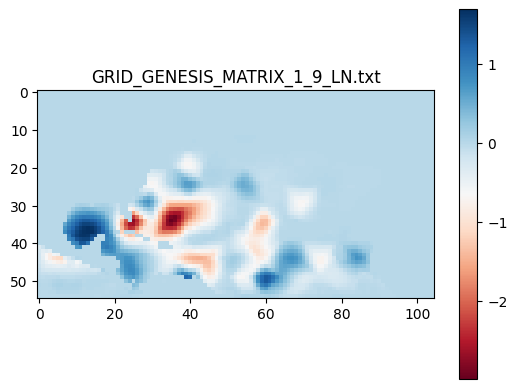

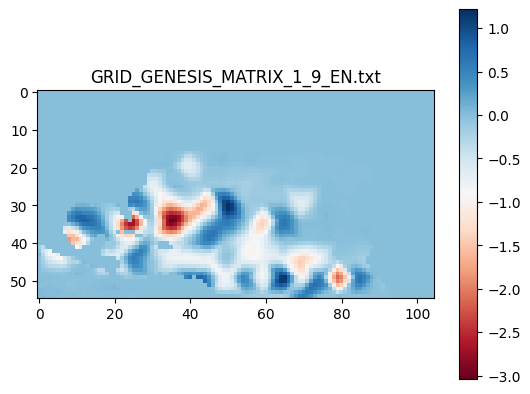

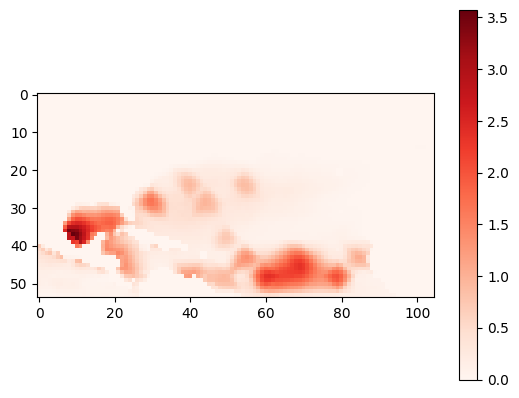

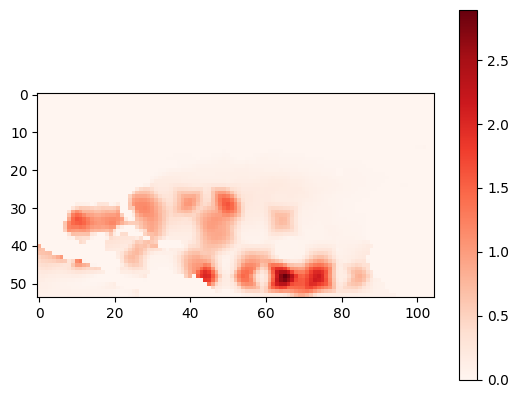

In [11]:
# path_files = "/home/mbaldacchino/data/SIENA-IH-STORM_10k2/"

path_files = "/home/mbaldacchino/data/SIENA-IH-STORM_VF/"
files = os.listdir(path_files)
files_txt = [file for file in files if file[-4:] == ".txt"]
files_npy = [file for file in files if file[-4:] == ".npy"]


lst_gen = [
    "GRID_GENESIS_MATRIX_1_9_LN.txt",
    "GRID_GENESIS_MATRIX_1_9_EN.txt",
]


for txt in lst_gen:
    plt.imshow(
        pd.read_csv(path_files + txt, sep=" ", header=None)
        - pd.read_csv(
            path_files + txt.replace("_EN", "_NEU").replace("_LN", "_NEU"),
            sep=" ",
            header=None,
        ),
        cmap="RdBu",
        # vmin=-0.0001,
        # vmax=0.0001,
    )
    plt.colorbar()
    plt.title(txt)
    plt.show()

plt.imshow(
    pd.read_csv(path_files + lst_gen[0], sep=" "),
    cmap="Reds",
)
plt.colorbar()
plt.show()
plt.imshow(
    pd.read_csv(path_files + lst_gen[1], sep=" "),
    cmap="Reds",
)
plt.colorbar()
plt.show()

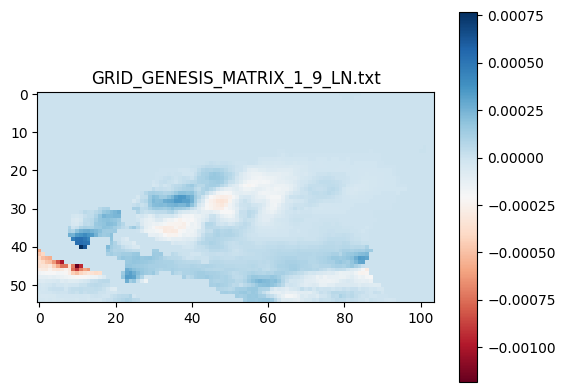

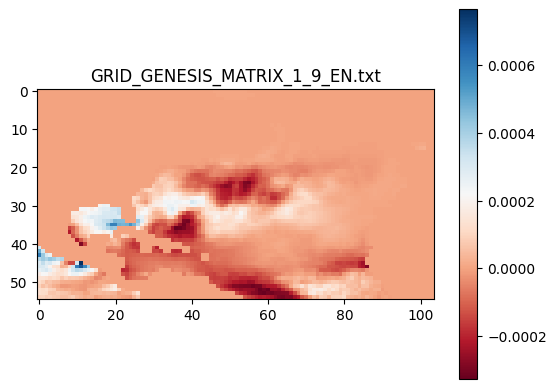

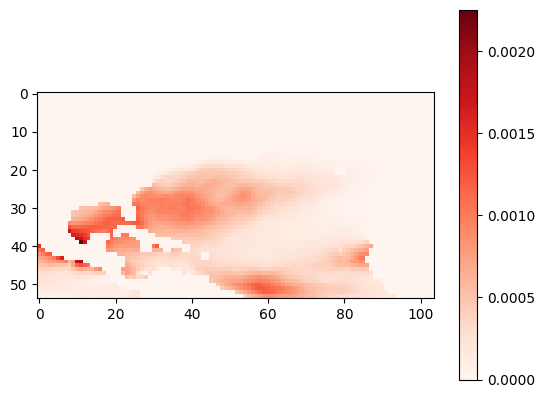

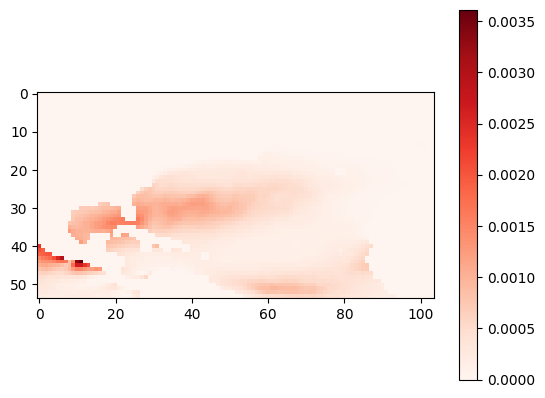

In [12]:
path_files = "/home/mbaldacchino/data/SIENA-IH-STORM_10k2/"
files = os.listdir(path_files)
files_txt = [file for file in files if file[-4:] == ".txt"]
files_npy = [file for file in files if file[-4:] == ".npy"]


lst_gen = [
    "GRID_GENESIS_MATRIX_1_9_LN.txt",
    "GRID_GENESIS_MATRIX_1_9_EN.txt",
]


for txt in lst_gen:
    plt.imshow(
        pd.read_csv(path_files + txt, sep=" ", header=None)
        - pd.read_csv(
            path_files + txt.replace("_EN", "_NEU").replace("_LN", "_NEU"),
            sep=" ",
            header=None,
        ),
        cmap="RdBu",
        # vmin=-0.0001,
        # vmax=0.0001,
    )
    plt.colorbar()
    plt.title(txt)
    plt.show()

plt.imshow(
    pd.read_csv(path_files + lst_gen[0], sep=" "),
    cmap="Reds",
)
plt.colorbar()
plt.show()
plt.imshow(
    pd.read_csv(path_files + lst_gen[1], sep=" "),
    cmap="Reds",
)
plt.colorbar()
plt.show()


# IH STORM

In [2]:
ibtracs_1980_2020 = TCTracks.from_ibtracs_netcdf(
    provider="usa",
    year_range=(1980, 2020),
    basin="NA",  # optional; use None if you do not want basin filtering
    estimate_missing=True,
)

STORM_EN_paths_old = [
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ELNINO/IB1980-2021ELNINO_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_0.txt",
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ELNINO/IB1980-2021ELNINO_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_1.txt",
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ELNINO/IB1980-2021ELNINO_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_2.txt",
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ELNINO/IB1980-2021ELNINO_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_3.txt",
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ELNINO/IB1980-2021ELNINO_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_4.txt",
]
STORM_LN_paths_old = [
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021LANINA/IB1980-2021LANINA_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_0.txt",
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021LANINA/IB1980-2021LANINA_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_1.txt",
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021LANINA/IB1980-2021LANINA_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_2.txt",
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021LANINA/IB1980-2021LANINA_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_3.txt",
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021LANINA/IB1980-2021LANINA_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_4.txt",
]
STORM_NEU_paths_old = [
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ENSO_NEUTRAL/IB1980-2021ENSO_NEUTRAL_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_0.txt",
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ENSO_NEUTRAL/IB1980-2021ENSO_NEUTRAL_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_1.txt",
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ENSO_NEUTRAL/IB1980-2021ENSO_NEUTRAL_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_2.txt",
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ENSO_NEUTRAL/IB1980-2021ENSO_NEUTRAL_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_3.txt",
    "/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ENSO_NEUTRAL/IB1980-2021ENSO_NEUTRAL_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_4.txt",
]


STORM_LN_paths = [
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_0.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_1.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_2.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_3.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_LN_1000_YEARS_4.txt",
]
STORM_EN_paths = [
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_0.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_1.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_2.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_3.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_EN_1000_YEARS_4.txt",
]
STORM_NEU_paths = [
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_0.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_1.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_2.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_3.txt",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_4.txt",
]

scenarios = {
    "EL_NINO": [TCTracks.from_simulations_storm(i) for i in STORM_EN_paths],
    "LA_NINA": [TCTracks.from_simulations_storm(i) for i in STORM_LN_paths],
    "NEUTRAL": [TCTracks.from_simulations_storm(i) for i in STORM_NEU_paths],
    "EL_NINO_old": [TCTracks.from_simulations_storm(i) for i in STORM_EN_paths_old],
    "LA_NINA_old": [TCTracks.from_simulations_storm(i) for i in STORM_LN_paths_old],
    "NEUTRAL_old": [TCTracks.from_simulations_storm(i) for i in STORM_NEU_paths_old],
    "IBTRACS_1980_2020": ibtracs_1980_2020,
}

US_BIG_CITIES = [
    {"city": "New York", "lat": 40.7128, "lon": -74.0060},
    {"city": "Miami", "lat": 25.7617, "lon": -80.1918},
    {"city": "Houston", "lat": 29.7604, "lon": -95.3698},
    {"city": "New Orleans", "lat": 29.9511, "lon": -90.0715},
    {"city": "Tampa", "lat": 27.9506, "lon": -82.4572},
    {"city": "Jacksonville", "lat": 30.3322, "lon": -81.6557},
    {"city": "Charleston", "lat": 32.7765, "lon": -79.9311},
    {"city": "Norfolk", "lat": 36.8508, "lon": -76.2859},
]

pooled_tracks, hazards, curves_wide, curves_long = (
    compare_city_rp_curves_across_scenarios(
        scenarios=scenarios,
        cities=US_BIG_CITIES,
        return_periods=np.geomspace(2, 500, 30),
        model="H08",
        exceedance_method="interpolate",
        bin_decimals=1,
        # Choose ONE of the two frequency approaches below:
        yearrange_by_scenario=None,
        effective_years_by_scenario={
            # Fill these with the actual number of ENSO-specific years represented
            # if you want conditional-on-phase return periods.
            # Example only:
            "EL_NINO": 5000,
            "LA_NINA": 5000,
            "NEUTRAL": 5000,
            "EL_NINO_old": 5000,
            "LA_NINA_old": 5000,
            "NEUTRAL_old": 5000,
            "IBTRACS_1980_2020": 41,
        },
        deduplicate_tracks=False,
    )
)


2026-03-29 14:13:51,653 - climada.hazard.tc_tracks - WARNING - The cached IBTrACS data set dates from 2025-06-04 02:47:07 (older than 180 days). Very likely, a more recent version is available. Consider manually removing the file /home/mbaldacchino/climada/data/IBTrACS.ALL.v04r01.nc and re-running this function, which will download the most recent version of the IBTrACS data set from the official URL.


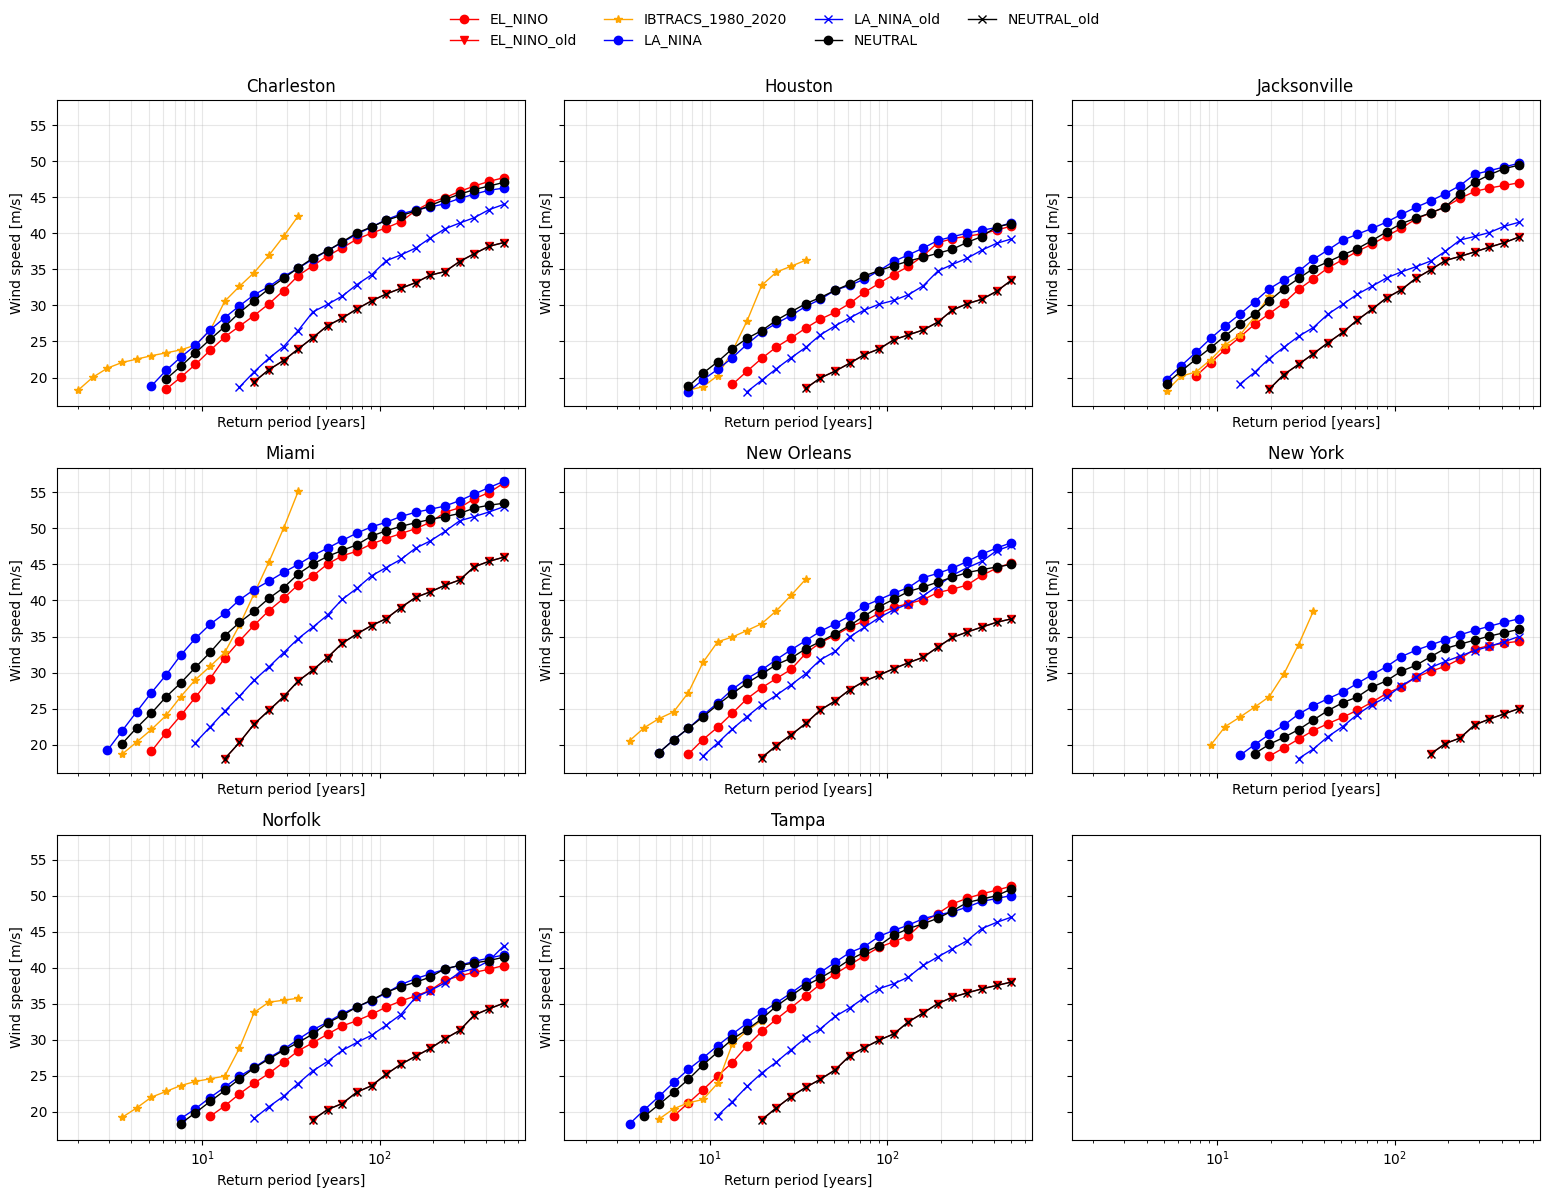

In [3]:
fig, axes = plot_rp_curves_by_city(
    curves_long,
    ncols=3,
    markers=["o", "v", "*", "o", "x", "o", "x"],
    colors=["red", "red", "orange", "blue", "blue", "black", "black"],
)
plt.show()


In [35]:
path_files = "/home/mbaldacchino/data/SIENA-IH-STORM_10k3/"
files = os.listdir(path_files)
files_txt = [file for file in files if file[-4:] == ".txt"]
files_npy = [file for file in files if file[-4:] == ".npy"]

path_files2 = "/home/mbaldacchino/data/SIENA-IH-STORM_10k4/"
files2 = os.listdir(path_files2)
files_txt2 = [file for file in files2 if file[-4:] == ".txt"]
files_npy2 = [file for file in files2 if file[-4:] == ".npy"]


# Spatial validation

In [13]:
import os
import sys
import subprocess

repo = "/home/mbaldacchino/code/SIENA-IH-STORM"
os.chdir(repo)

cmd = [
    sys.executable,
    "VALIDATION_spatial.py",
    "--basins",
    "NA",
    "--ibtracs_years",
    "41",
    "--sim_years",
    "10000",
    "--storm_pattern",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_{basin}_{phase}_*_YEARS_*.txt",
    "--outdir",
    "validation_plots",
]

subprocess.run(cmd, check=True)



Validation for basin: NA
  Loading IBTrACS...
  Loading EN...
  Loading NEU...
  Loading LN...
  Datasets loaded: ['IBTrACS', 'EN', 'NEU', 'LN']
    IBTrACS: 471 storms, 20,234 track points
    EN: 82,689 storms, 3,151,036 track points
    NEU: 113,241 storms, 3,935,057 track points
    LN: 135,472 storms, 5,065,181 track points

  Plotting genesis density...
  Saved: validation_plots/validation_genesis_NA.png
  Plotting track density...
  Saved: validation_plots/validation_track_density_NA.png
  Plotting ACE density...
  Saved: validation_plots/validation_ace_NA.png
  Plotting LMI distribution...
  Saved: validation_plots/validation_lmi_NA.png
  Plotting wind-pressure scatter...
  Saved: validation_plots/validation_wpr_NA.png

All plots saved to: validation_plots/


CompletedProcess(args=['/home/mbaldacchino/miniconda/envs/cat/bin/python', 'VALIDATION_spatial.py', '--basins', 'NA', '--ibtracs_years', '41', '--sim_years', '10000', '--storm_pattern', '/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_{basin}_{phase}_*_YEARS_*.txt', '--outdir', 'validation_plots'], returncode=0)

# Spatial comparison

In [1]:
import os
import sys
import subprocess

repo = "/home/mbaldacchino/code/SIENA-IH-STORM"
os.chdir(repo)

cmd = [
    sys.executable,
    "VALIDATION_difference.py",
    "--basins",
    "NA",
    "--ibtracs_years",
    "41",
    "--sim_years_new",
    "10000",
    "--resolution",
    "1.0",
    "--new_pattern",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_{basin}_{phase}_*_YEARS_*.txt",
    "--outdir",
    "validation_diff_plots",
]

subprocess.run(cmd, check=True)



Difference maps for: NA
  Loading IBTrACS...
  New EN: 82,689 storms
  New NEU: 113,241 storms
  New LN: 135,472 storms

  Computing Genesis Density...


/home/mbaldacchino/code/SIENA-IH-STORM/VALIDATION_difference.py:443: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Saved: validation_diff_plots/diff_genesis_density_NA.png

  Computing Track Density...


/home/mbaldacchino/code/SIENA-IH-STORM/VALIDATION_difference.py:443: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Saved: validation_diff_plots/diff_track_density_NA.png

  Computing ACE Density...


/home/mbaldacchino/code/SIENA-IH-STORM/VALIDATION_difference.py:443: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Saved: validation_diff_plots/diff_ace_density_NA.png

All plots saved to: validation_diff_plots/


CompletedProcess(args=['/home/mbaldacchino/miniconda/envs/cat/bin/python', 'VALIDATION_difference.py', '--basins', 'NA', '--ibtracs_years', '41', '--sim_years_new', '10000', '--resolution', '1.0', '--new_pattern', '/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_{basin}_{phase}_*_YEARS_*.txt', '--outdir', 'validation_diff_plots'], returncode=0)

In [10]:
from pathlib import Path
import os

outdir = Path("/home/mbaldacchino/data/old_storm_flat")
outdir.mkdir(parents=True, exist_ok=True)

for i in range(10):
    links = [
        (
            f"/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ELNINO/IB1980-2021ELNINO_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_{i}.txt",
            outdir / f"STORM_DATA_IBTRACS_NA_EN_1000_YEARS_{i}.txt",
        ),
        (
            f"/home/mbaldacchino/data/STORM_ENSO/IB1980-2021LANINA/IB1980-2021LANINA_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_{i}.txt",
            outdir / f"STORM_DATA_IBTRACS_NA_LN_1000_YEARS_{i}.txt",
        ),
        (
            f"/home/mbaldacchino/data/STORM_ENSO/IB1980-2021ENSO_NEUTRAL/IB1980-2021ENSO_NEUTRAL_nanfilled/STORM_DATA_IBTRACS_NA_1000_YEARS_{i}.txt",
            outdir / f"STORM_DATA_IBTRACS_NA_NEU_1000_YEARS_{i}.txt",
        ),
    ]

    for src, dst in links:
        if dst.exists() or dst.is_symlink():
            dst.unlink()
        os.symlink(src, dst)




In [14]:
import os
import sys
import subprocess

repo = "/home/mbaldacchino/code/SIENA-IH-STORM"
os.chdir(repo)


cmd = [
    sys.executable,
    "VALIDATION_difference.py",
    "--basins",
    "NA",
    "--ibtracs_years",
    "41",
    "--sim_years_new",
    "10000",
    "--sim_years_old",
    "10000",
    "--resolution",
    "3.0",
    "--new_pattern",
    "/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_{basin}_{phase}_*_YEARS_*.txt",
    "--old_pattern",
    "/home/mbaldacchino/data/old_storm_flat/STORM_DATA_IBTRACS_{basin}_{phase}_*_YEARS_*.txt",
    "--outdir",
    "validation_diff_plots_bis",
    "--old_has_phases",
]

subprocess.run(cmd, check=True)



Difference maps for: NA
  Loading IBTrACS...
  New EN: 82,689 storms
  New NEU: 113,241 storms
  New LN: 135,472 storms
  Old EN: 48,764 storms
  Old NEU: 48,764 storms
  Old LN: 94,001 storms

  Computing Genesis Density...


/home/mbaldacchino/code/SIENA-IH-STORM/VALIDATION_difference.py:443: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Saved: validation_diff_plots_bis/diff_genesis_density_NA.png

  Computing Track Density...


/home/mbaldacchino/code/SIENA-IH-STORM/VALIDATION_difference.py:443: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Saved: validation_diff_plots_bis/diff_track_density_NA.png

  Computing ACE Density...


/home/mbaldacchino/code/SIENA-IH-STORM/VALIDATION_difference.py:443: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Saved: validation_diff_plots_bis/diff_ace_density_NA.png

All plots saved to: validation_diff_plots_bis/


CompletedProcess(args=['/home/mbaldacchino/miniconda/envs/cat/bin/python', 'VALIDATION_difference.py', '--basins', 'NA', '--ibtracs_years', '41', '--sim_years_new', '10000', '--sim_years_old', '10000', '--resolution', '3.0', '--new_pattern', '/home/mbaldacchino/data/SIENA-IH-STORM_VF/STORM_DATA_IBTRACS_{basin}_{phase}_*_YEARS_*.txt', '--old_pattern', '/home/mbaldacchino/data/old_storm_flat/STORM_DATA_IBTRACS_{basin}_{phase}_*_YEARS_*.txt', '--outdir', 'validation_diff_plots_bis', '--old_has_phases'], returncode=0)